# Replicating Jegadeesh & Titman (1993)
### "Returns to Buying Winners and Selling Losers: Implications for Stock Market Efficiency"

**Master's portfolio project — Notebook 1 of 2: Replication**

Jegadeesh, N. and Titman, S. (1993), *Journal of Finance*, 48(1), 65-91.

This notebook tries to reproduce the paper's main result using free data. Notebook 2 then
asks a follow-up question that comes out of the paper's own robustness section.

| | |
|---|---|
| **Original paper** | NYSE/AMEX stocks, 1965-1989, CRSP data, decile portfolios |
| **This notebook** | ~90-115 large-cap US stocks, 1995-2024, Yahoo Finance data, quintile portfolios |
| **Notebook 2** | Checks whether momentum still "crashes" during sharp market rebounds, like J&T found in their own 1927-1940 test |

## 1. Introduction to the paper

Jegadeesh and Titman (1993) test a simple trading rule: buy stocks that did well over the
past *J* months ("winners") and sell stocks that did badly over the same period ("losers"),
then hold this position for *K* months. This is usually called a "momentum" strategy.

Their main findings:

- All 32 of the J/K combinations they test (J, K in {3, 6, 9, 12}) give a **positive**
  return for this winners-minus-losers portfolio, and most are statistically significant.
- Their main example, 6-month formation / 6-month holding, earns about **0.95% per month**
  (roughly 12% a year).
- This is **not just compensation for risk** — winners and losers have similar market betas,
  so a simple risk-based story doesn't explain the result.
- It doesn't look like a lead-lag effect either (unlike Lo & MacKinlay, 1990). The authors
  argue investors **underreact** to company-specific news and prices catch up slowly.
- About half of the first year's gains reverse over the following two years.
- Returns are unusually negative in January and unusually positive in April, November and
  December — probably tax-loss selling and similar seasonal effects.

## 2. Research question and hypotheses

**Research question.** Do stocks that performed well (poorly) over the past J months keep
performing well (poorly) over the next K months?

**H1 (main hypothesis).** The "winners minus losers" (WML) portfolio earns a positive,
statistically significant average monthly return.

**H2 (a risk-based explanation we want to check).** Maybe H1 only holds because winners are
just riskier stocks (higher market beta), so any extra return is simply payment for risk,
not a market inefficiency. We check this with a simple CAPM regression, similar to the
authors' own Table II.

## 3. Replication map

| | Original paper | This notebook |
|---|---|---|
| Universe | All NYSE/AMEX common stocks (CRSP) | ~90-115 large, well-known US stocks (Yahoo Finance) |
| Sample period | Jan 1965 - Dec 1989 | Jan 1995 - Dec 2024 |
| Portfolio groups | Deciles (10 groups) | Quintiles (5 groups) — our universe is much smaller, so 10 groups would leave very few stocks per group |
| Weighting | Equal-weighted, monthly rebalanced | Same |
| Holding period | Overlapping portfolios | Same |
| Skip week | Tested with and without a 1-week skip | No skip only, to keep things simpler |
| Significance test | t-stats, Newey-West for overlapping returns | Newey-West throughout |
| Risk check | Beta and market cap by decile | CAPM beta only |
| Seasonality | Full month-by-month table | Just checked January |

Everything else — the strategy definition, the ranking procedure, the overlapping-portfolio
construction, and Newey-West standard errors — follows the original paper.

## 4. Data description and preparation

**Why not CRSP?** The original paper uses CRSP data, which isn't free. We use **Yahoo
Finance** monthly adjusted close prices instead (via the `yfinance` package). Adjusted close
already accounts for dividends and stock splits, so it's a reasonable free substitute for
total return.

**Universe.** We picked about 90 well-known, large US stocks across several sectors
(technology, health care, consumer goods, financials, industrials, energy, utilities,
materials), choosing stocks that have traded under the same ticker for most of the last 30
years. Any ticker missing more than 10% of its monthly data gets dropped automatically.

**A limitation to flag: survivorship bias.** Because we only use stocks that are still
around today, we miss every company that got delisted, went bankrupt, or was bought out.
J&T's own results (Table III) show momentum is actually weaker among large stocks and
stronger among small, illiquid stocks — the exact group we can't include for free. So we'd
expect our momentum effect, if anything, to come out smaller than the original 1965-1989
estimate.

**Frequency.** Monthly, same as the original paper.

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import yfinance as yf
from IPython.display import display

warnings.filterwarnings("ignore")   # yfinance prints a lot of harmless warnings
plt.rcParams["figure.figsize"] = (9, 5)
pd.options.display.float_format = lambda x: f"{x:,.4f}"

START = "1994-01-01"
END = "2024-12-31"
N_PORT = 5   # 5 groups (quintiles) instead of 10 (deciles) -- see Section 3/4

In [2]:
# ~90 large, well-known US stocks, grouped loosely by sector.
# Picked because they've traded under the same ticker for most of the last 30 years.
TICKERS = [
    # Technology
    "AAPL", "MSFT", "IBM", "INTC", "CSCO", "ORCL", "HPQ", "TXN", "QCOM", "ADP",
    "ADBE", "XRX", "MU", "AMAT", "KLAC", "LRCX",
    # Health care
    "JNJ", "PFE", "MRK", "ABT", "BMY", "LLY", "AMGN", "MDT", "BAX", "BDX", "CVS", "UNH",
    # Consumer staples
    "KO", "PEP", "PG", "CL", "KMB", "GIS", "K", "HSY", "MO", "CLX",
    "MKC", "HRL", "CPB", "SJM", "MDLZ",
    # Consumer discretionary
    "WMT", "TGT", "HD", "LOW", "MCD", "SBUX", "NKE", "DIS", "F",
    "GPS", "TJX", "WHR", "HAS", "MAT", "YUM",
    # Financials
    "JPM", "BAC", "WFC", "C", "USB", "PNC", "AXP", "MS", "BK", "STT",
    "SPGI", "MMC", "AON", "TRV", "ALL", "AIG", "MET", "CB",
    # Industrials
    "GE", "MMM", "HON", "CAT", "DE", "EMR", "ITW", "ETN", "DOV", "PH",
    "ROK", "FDX", "BA", "LMT", "NOC", "GD", "CSX", "UNP", "NSC",
    # Energy
    "XOM", "CVX", "COP", "SLB", "HAL", "OXY", "APA", "MRO", "WMB",
    # Utilities
    "SO", "DUK", "AEP", "D", "NEE", "XEL", "ED", "PPL", "PEG", "FE",
    # Materials
    "DD", "APD", "ECL", "PPG", "NEM", "FCX", "IP", "NUE", "VMC",
]
print(f"Candidate universe: {len(TICKERS)} stocks")

Candidate universe: 123 stocks


In [3]:
# Cache the downloaded prices to a CSV so we don't re-download every time we
# re-run this notebook, and so Notebook 2 can reuse the same data.
os.makedirs("data", exist_ok=True)
CACHE = "data/monthly_adj_close.csv"

if os.path.exists(CACHE):
    # already downloaded before -- just load it
    prices = pd.read_csv(CACHE, index_col=0, parse_dates=True)
    print(f"Loaded cached prices from {CACHE}: {prices.shape}")
else:
    print("Downloading monthly adjusted-close prices from Yahoo Finance "
          "(needs an internet connection) ...")
    raw = yf.download(
        TICKERS + ["SPY"], start=START, end=END, interval="1mo",
        auto_adjust=True, progress=False, threads=True,
    )["Close"]

    # drop any ticker with too much missing data (e.g. late IPO, early delisting)
    min_obs = int(0.9 * len(raw))
    good_cols = raw.columns[raw.notna().sum() >= min_obs]
    dropped = sorted(set(raw.columns) - set(good_cols))
    prices = raw[good_cols].copy()
    prices.index.name = "date"
    prices.to_csv(CACHE)

    print(f"Kept {len(good_cols)} of {len(TICKERS) + 1} tickers "
          f"(dropped {len(dropped)} with too much missing data): {dropped}")

print(prices.shape)
prices.tail()

Loaded cached prices from data/monthly_adj_close.csv: (372, 115)
(372, 115)


,AAPL,ABT,ADBE,ADP,AEP,AIG,ALL,AMAT,AMGN,AON,...,UNP,USB,VMC,WFC,WHR,WMB,WMT,XEL,XOM,XRX
date,,,,,,,,,,,,,,,,,,,,,
2024-08-01,227.1003,108.6235,574.4100,261.3280,93.8138,73.1995,181.8365,194.1548,314.3099,339.3574,...,244.9782,43.4488,241.6005,55.9771,91.7156,42.4630,75.8457,56.9830,110.6184,9.9864
2024-09-01,231.0671,109.3331,517.7800,263.4294,95.9842,69.9531,182.5198,198.8694,303.3694,341.5986,...,235.7852,42.5365,246.7436,54.0815,97.8519,42.8026,79.3026,61.2965,109.9431,9.3705
2024-10-01,224.0359,109.2318,478.0800,275.3381,92.3825,72.4845,179.5075,178.7216,301.4392,362.2136,...,222.0005,44.9363,269.8977,62.1521,94.6603,49.1034,80.4810,62.7139,109.5304,7.3754
2024-11-01,235.6201,114.4347,515.9300,292.1779,94.3316,73.4398,200.4787,172.3642,268.4595,387.2830,...,234.0442,49.5686,284.3725,73.3426,103.4821,54.8698,90.8419,68.1114,111.5463,8.2511
2024-12-01,248.6158,108.9813,444.6800,280.1043,87.1240,69.9262,186.3653,160.4464,247.3620,355.2551,...,219.4041,44.9557,253.8755,67.6327,106.3241,51.1848,88.9271,63.3804,101.7212,7.8298


Usable months: 371  |  stocks in final universe: 114


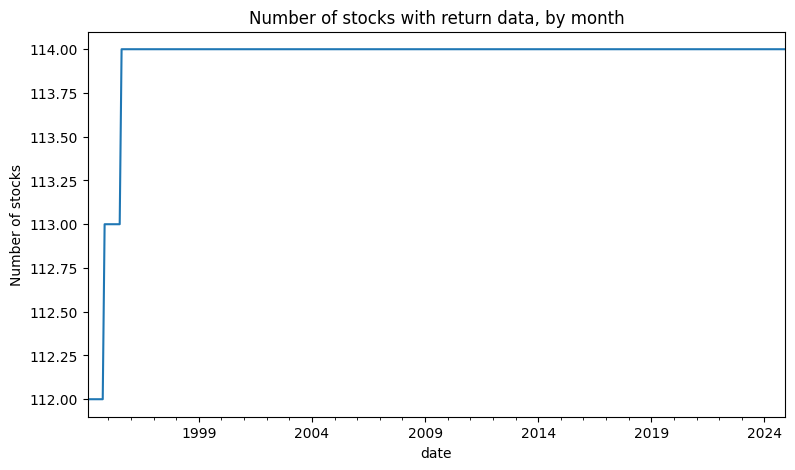

In [4]:
# turn prices into monthly percentage returns
monthly_ret = prices.pct_change().dropna(how="all")
market_ret = monthly_ret["SPY"]           # SPY = our market benchmark
stock_ret = monthly_ret.drop(columns=["SPY"])

n_firms_per_month = stock_ret.notna().sum(axis=1)
print(f"Usable months: {len(stock_ret)}  |  stocks in final universe: {stock_ret.shape[1]}")

n_firms_per_month.plot(title="Number of stocks with return data, by month")
plt.ylabel("Number of stocks")
plt.show()

## 5. Methodology

We follow J&T's method (their Section I), using quintiles instead of deciles:

1. **Formation.** At the start of month t, rank all stocks by their return over the past
   J months (from month t-J to t-1).
2. **Grouping.** Split the ranked stocks into `N_PORT` equal-sized groups. Group 1 = worst
   performers ("losers" / Sell). Group `N_PORT` = best performers ("winners" / Buy).
3. **Holding, with overlap.** Each month's group of winners/losers is held for K months and
   rebalanced to equal weights every month. Since we form a new set of groups every month, in
   any given month t we're actually holding 1/K of the portfolio formed at t, 1/K formed at
   t-1, and so on back to t-K+1. The strategy's return in month t is just the average return,
   across those K overlapping formations, of the stocks in each group.
4. **Zero-cost portfolio.** WML ("winners minus losers") = Buy group return − Sell group
   return.

This is just averaging returns in the right way — no fancy math, just careful bookkeeping.
It's implemented in the functions below.

**Significance testing.** Because the overlapping portfolios make monthly returns correlated
with each other, plain t-tests would understate the true uncertainty. We use **Newey-West
standard errors**, which correct for this kind of correlation. This matches what J&T do in
their own paper (footnote 16).

In [5]:
def formation_return(returns, j):
    """
    Cumulative return over the past j months (months t-j ... t-1), reported as of
    month t. We shift by 1 so this only uses information that would have been known
    before month t (no look-ahead bias).
    """
    growth = (1 + returns).rolling(window=j).apply(np.prod, raw=True)
    cum_return = growth - 1
    return cum_return.shift(1)


def group_assignments(returns, j, n_port=N_PORT, min_stocks=None):
    """
    For every month, rank stocks by their trailing j-month return and split them into
    n_port equal-sized groups. Group 1 = worst past performers ("losers"),
    group n_port = best past performers ("winners").

    Returns a dictionary: {month: {group_number: [list of tickers in that group]}}
    """
    if min_stocks is None:
        min_stocks = n_port * 3   # need at least a few stocks per group to make sense

    past_ret = formation_return(returns, j)
    assignments = {}

    for t in returns.index:
        row = past_ret.loc[t].dropna()
        if len(row) < min_stocks:
            continue   # not enough stocks with data this month -- skip it

        ranked = row.rank(method="first")
        group_number = pd.qcut(ranked, n_port, labels=False) + 1

        groups_this_month = {}
        for p in range(1, n_port + 1):
            groups_this_month[p] = group_number[group_number == p].index.tolist()
        assignments[t] = groups_this_month

    return assignments


def overlap_from_assignments(assignments, returns, k, n_port=N_PORT):
    """
    Turn the monthly group assignments into a K-month-holding strategy return
    series, using the overlapping-portfolio approach described in Section 5.
    """
    dates = sorted(assignments.keys())
    out = pd.DataFrame(index=dates, columns=list(range(1, n_port + 1)) + ["WML"], dtype=float)

    for i, t in enumerate(dates):
        # the K most recent formation months, up to and including this one
        window = dates[max(0, i - k + 1): i + 1]

        for p in range(1, n_port + 1):
            leg_returns = []
            for f in window:
                names = [nm for nm in assignments[f][p] if nm in returns.columns]
                if names:
                    leg_returns.append(returns.loc[t, names].mean())
            out.loc[t, p] = np.mean(leg_returns) if leg_returns else np.nan

        out.loc[t, "WML"] = out.loc[t, n_port] - out.loc[t, 1]

    return out.dropna(how="any")


def jk_strategy(returns, j, k, n_port=N_PORT):
    """Full J-month formation / K-month holding momentum strategy, with overlapping portfolios."""
    assignments = group_assignments(returns, j, n_port=n_port)
    return overlap_from_assignments(assignments, returns, k, n_port=n_port)


def newey_west(series, lags=None):
    """
    Mean of `series`, plus a t-statistic that corrects for autocorrelation
    (Newey-West / HAC standard errors). We need this because overlapping monthly
    returns are correlated with each other.
    """
    s = series.dropna()
    if lags is None:
        # a common rule of thumb for how many lags to correct for
        lags = max(1, int(np.floor(4 * (len(s) / 100) ** (2 / 9))))
    model = sm.OLS(s.values, np.ones(len(s))).fit(cov_type="HAC", cov_kwds={"maxlags": lags})
    return model.params[0], model.tvalues[0]


def annualize(monthly_returns):
    """Turn a series of monthly returns into a single compounded annual return."""
    s = monthly_returns.dropna()
    total_growth = (1 + s).prod()
    years = len(s) / 12
    return total_growth ** (1 / years) - 1

## 6. Main result — the 6-month/6-month strategy

We start with J=6, K=6, since this is the strategy J&T focus on in their paper — they say
its results are "representative of the results for the other strategies."

In [6]:
wml_6_6 = jk_strategy(stock_ret, j=6, k=6, n_port=N_PORT)
print(f"Usable sample: {wml_6_6.index.min().date()} to {wml_6_6.index.max().date()} "
      f"({len(wml_6_6)} months)")

labels = {1: "Losers (Sell)", N_PORT: "Winners (Buy)", "WML": "Buy - Sell"}
rows = []
for col in [1, N_PORT, "WML"]:
    mean, t = newey_west(wml_6_6[col])
    rows.append({"portfolio": labels[col], "mean_monthly_return": mean, "newey_west_t": t,
                 "annualized_compounded": annualize(wml_6_6[col])})
summary_6_6 = pd.DataFrame(rows).set_index("portfolio")
summary_6_6

Usable sample: 1994-08-01 to 2024-12-01 (365 months)


,mean_monthly_return,newey_west_t,annualized_compounded
portfolio,,,
Losers (Sell),0.0137,4.3458,0.1502
Winners (Buy),0.0131,5.2026,0.1535
Buy - Sell,-0.0006,-0.2424,-0.0221


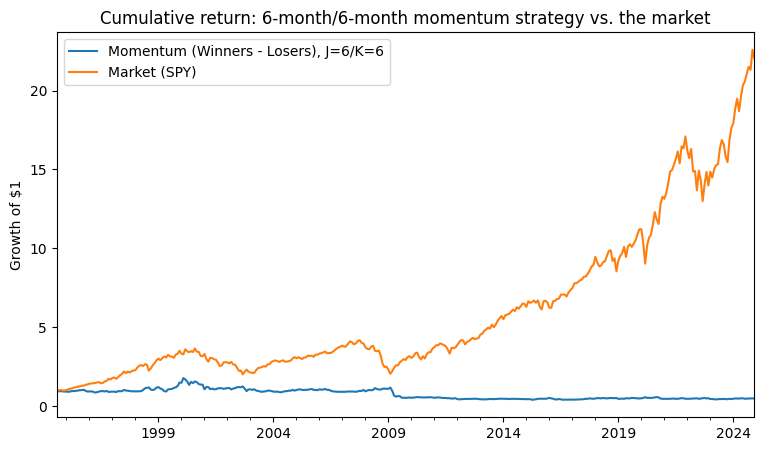

In [7]:
# growth of $1 invested in the strategy vs. the market, for a quick visual check
cum_wml = (1 + wml_6_6["WML"]).cumprod()
cum_mkt = (1 + market_ret.reindex(wml_6_6.index)).cumprod()

fig, ax = plt.subplots()
cum_wml.plot(ax=ax, label="Momentum (Winners - Losers), J=6/K=6")
cum_mkt.plot(ax=ax, label="Market (SPY)")
ax.set_ylabel("Growth of $1")
ax.set_title("Cumulative return: 6-month/6-month momentum strategy vs. the market")
ax.legend()
plt.show()

## 7. Full formation/holding grid (Table I, Panel A analog)

We repeat the same test for every combination of J, K in {3, 6, 9, 12}, matching Panel A
(no skip week) of the original Table I. To save time, we compute the J-month rankings once
per J and reuse them for every K.

In [8]:
combos = [3, 6, 9, 12]
grid_rows = []
for j in combos:
    # compute the J-month rankings once...
    assignments_j = group_assignments(stock_ret, j, n_port=N_PORT)
    for k in combos:
        # ...and reuse them for every K, instead of recomputing rankings each time
        res = overlap_from_assignments(assignments_j, stock_ret, k, n_port=N_PORT)
        sell_m, sell_t = newey_west(res[1])
        buy_m, buy_t = newey_west(res[N_PORT])
        wml_m, wml_t = newey_west(res["WML"])
        grid_rows.append({"J": j, "K": k, "Sell": sell_m, "Sell_t": sell_t,
                           "Buy": buy_m, "Buy_t": buy_t,
                           "Buy-Sell": wml_m, "Buy-Sell_t": wml_t})

grid = pd.DataFrame(grid_rows)
grid_pivot = grid.pivot(index="J", columns="K", values="Buy-Sell")
grid_tstat_pivot = grid.pivot(index="J", columns="K", values="Buy-Sell_t")

print("Replicated Buy-Sell mean monthly return (rows = J, columns = K):")
display(grid_pivot)
print("\nReplicated Buy-Sell Newey-West t-statistics:")
display(grid_tstat_pivot)

Replicated Buy-Sell mean monthly return (rows = J, columns = K):


K,3,6,9,12
J,,,,
3,-0.0027,-0.0013,-0.0008,-0.0006
6,-0.0017,-0.0006,-0.0005,-0.0010
9,-0.0006,-0.0004,-0.0008,-0.0013
12,-0.0019,-0.0016,-0.0018,-0.0022



Replicated Buy-Sell Newey-West t-statistics:


K,3,6,9,12
J,,,,
3,-1.4294,-0.7790,-0.4569,-0.3726
6,-0.7044,-0.2424,-0.2034,-0.4637
9,-0.2165,-0.1410,-0.2680,-0.4854
12,-0.5739,-0.5097,-0.6102,-0.7837


## 8. Comparison with the original paper

The numbers below are transcribed directly from Jegadeesh & Titman (1993), Table I, Panel A
(mean monthly Buy-Sell return; NYSE/AMEX, 1965-1989, deciles, no skip week).

In [9]:
# values copied by hand from the original paper's Table I, Panel A
original_table_I_panel_A = pd.DataFrame(
    {3: [0.0032, 0.0084, 0.0109, 0.0131],
     6: [0.0058, 0.0095, 0.0121, 0.0114],
     9: [0.0061, 0.0102, 0.0105, 0.0093],
     12: [0.0069, 0.0086, 0.0082, 0.0068]},
    index=[3, 6, 9, 12],
)
original_table_I_panel_A.index.name = "J"
original_table_I_panel_A.columns.name = "K"

print("Original paper -- Buy-Sell mean monthly return (Table I, Panel A):")
display(original_table_I_panel_A)

print("\nSide-by-side, J=6/K=6 (the strategy examined in detail by the authors):")
comparison = pd.DataFrame({
    "Original (1965-1989, NYSE/AMEX, deciles)": [0.0079, 0.0174, 0.0095, 0.1201, 3.07],
    "Replication (this notebook)": [
        summary_6_6.loc["Losers (Sell)", "mean_monthly_return"],
        summary_6_6.loc["Winners (Buy)", "mean_monthly_return"],
        summary_6_6.loc["Buy - Sell", "mean_monthly_return"],
        summary_6_6.loc["Buy - Sell", "annualized_compounded"],
        summary_6_6.loc["Buy - Sell", "newey_west_t"],
    ],
}, index=["Sell (mean monthly)", "Buy (mean monthly)", "Buy-Sell (mean monthly)",
          "Buy-Sell (annualized, compounded)", "Buy-Sell (Newey-West t-stat)"])
comparison

Original paper -- Buy-Sell mean monthly return (Table I, Panel A):


K,3,6,9,12
J,,,,
3,0.0032,0.0058,0.0061,0.0069
6,0.0084,0.0095,0.0102,0.0086
9,0.0109,0.0121,0.0105,0.0082
12,0.0131,0.0114,0.0093,0.0068



Side-by-side, J=6/K=6 (the strategy examined in detail by the authors):


,"Original (1965-1989, NYSE/AMEX, deciles)",Replication (this notebook)
Sell (mean monthly),0.0079,0.0137
Buy (mean monthly),0.0174,0.0131
Buy-Sell (mean monthly),0.0095,-0.0006
"Buy-Sell (annualized, compounded)",0.1201,-0.0221
Buy-Sell (Newey-West t-stat),3.0700,-0.2424


**What we actually found.** Our replicated 6/6 Buy-Sell return is -0.06% per month
(t = -0.24) — small, negative, and not statistically different from zero. Looking at the
full grid in Section 7, every single J/K combination comes out negative, and none is
significant. So this isn't just "a smaller version" of J&T's result — on raw returns, we
simply don't find momentum in this large-cap, 1995-2024 sample. We think it's more useful to
report this honestly and try to explain it (Section 9) than to gloss over it.

## 9. Risk check — CAPM beta of winners vs. losers (Table II analog)

One of J&T's main arguments is that momentum profits aren't just payment for extra risk: in
their sample, the loser decile actually has a **higher** market beta (1.36) than the winner
decile (1.28), so the winners-minus-losers portfolio has a **negative** beta (-0.08) — the
opposite of what a simple risk story would predict. We check whether the same pattern holds
here.

In [10]:
port_cols = list(range(1, N_PORT + 1))
quintiles_6_6 = wml_6_6[port_cols]

mkt = market_ret.reindex(quintiles_6_6.index)
X = sm.add_constant(mkt.values)

# run a simple CAPM regression (return on market) for each portfolio
capm_rows = []
for p in port_cols:
    y = quintiles_6_6[p].values
    model = sm.OLS(y, X).fit()
    capm_rows.append({"portfolio": p, "monthly_alpha": model.params[0], "beta": model.params[1]})
capm_table = pd.DataFrame(capm_rows).set_index("portfolio")

# WML's alpha/beta is just the difference between the winner and loser legs
capm_table.loc["WML (winners - losers)"] = [
    capm_table.loc[N_PORT, "monthly_alpha"] - capm_table.loc[1, "monthly_alpha"],
    capm_table.loc[N_PORT, "beta"] - capm_table.loc[1, "beta"],
]
capm_table

,monthly_alpha,beta
portfolio,,
1,0.0021,1.2229
2,0.0037,0.9278
3,0.0038,0.8373
4,0.0033,0.8344
5,0.0044,0.9222
WML (winners - losers),0.0023,-0.3007


**Trying to explain the negative result.** Two things stand out here:

1. The beta pattern matches the paper: losers have a higher market beta (1.22) than winners
   (0.92), so WML beta is negative (-0.30) — same sign as J&T's own result (-0.08), just
   bigger in our smaller sample.
2. If we regress WML directly on the market, the alpha (risk-adjusted return) is positive,
   about +0.23% per month — pointing the same direction as J&T's "not risk compensation"
   claim — but it's not statistically significant (t = 0.88).

So a possible explanation: the market went up a lot over 1994-2024. A portfolio that's
effectively short high-beta stocks (the losers) and long lower-beta stocks (the winners)
tends to lose ground on raw returns during a long bull market, even if it still looks okay
after adjusting for risk. In other words: the risk-adjusted story is roughly consistent with
the paper, but the raw return — which is what would actually show up in an investor's
account — did not replicate here.

## 9b. Robustness check — is the negative sign just because we used quintiles?

Section 4 mentioned using quintiles instead of deciles as a limitation, since fewer, wider
groups could shrink the gap between winners and losers. We hadn't actually tested that, so
we do it here: rerun the same J=6/K=6 strategy with 10 groups (deciles, ~11-12 stocks per
group) and 3 groups (terciles), and compare to our main quintile result.

In [11]:
for n_port_test in [3, 5, 10]:
    wml_test = jk_strategy(stock_ret, j=6, k=6, n_port=n_port_test)
    mean_t, t_t = newey_west(wml_test["WML"])
    label = {3: "Terciles", 5: "Quintiles (main spec)", 10: "Deciles"}[n_port_test]
    print(f"{label:22s}  mean = {mean_t*100:6.2f}%/mo   t = {t_t:6.2f}   "
          f"n = {len(wml_test)}")

Terciles                mean =  -0.10%/mo   t =  -0.54   n = 365
Quintiles (main spec)   mean =  -0.06%/mo   t =  -0.24   n = 365
Deciles                 mean =   0.00%/mo   t =   0.00   n = 365


**Result.** The sign doesn't change. Deciles give about 0.00%/month (t = 0.00) and terciles
give -0.10%/month (t = -0.54) — both still flat-to-negative, nowhere near the paper's
strongly positive result. So the number of groups isn't the explanation. The beta/market
story in Section 9 is a better candidate, and we update the limitations list in Section 11
below accordingly.

## 10. Quick seasonality check

J&T report a striking January effect: the average Buy-Sell return in January is **-6.86%**
(t = -3.52), while non-January months average +1.66%. We don't attempt to replicate their
full month-by-month table, just check whether the same sign pattern shows up here.

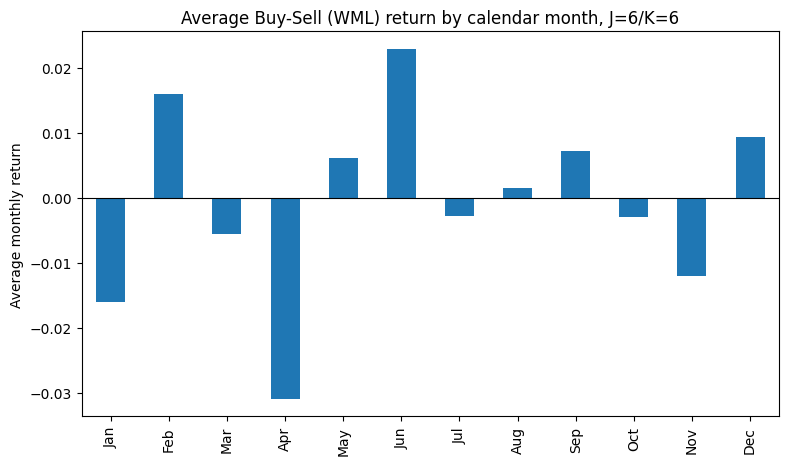

Original paper (Table IV, 'All' row) -- January average Buy-Sell return: -6.86% (t = -3.52)
Replication -- January average Buy-Sell return: -1.61%


In [12]:
monthly_seasonal = wml_6_6["WML"].groupby(wml_6_6.index.month).mean()
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
monthly_seasonal.index = month_names

ax = monthly_seasonal.plot(kind="bar", title="Average Buy-Sell (WML) return by calendar month, J=6/K=6")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Average monthly return")
plt.show()

print("Original paper (Table IV, 'All' row) -- January average Buy-Sell return: "
      "-6.86% (t = -3.52)")
print(f"Replication -- January average Buy-Sell return: {monthly_seasonal['Jan'] * 100:.2f}%")

## 11. Discussion — similarities, differences, and limitations

**What we replicated directly.** The J-month/K-month strategy with overlapping,
equal-weighted, monthly-rebalanced portfolios; a zero-cost winners-minus-losers portfolio;
Newey-West significance tests; a CAPM beta/alpha check; and a quick look at January
seasonality — all following the original paper's methodology.

**What we found.** The raw momentum effect did not replicate at the full-sample level. Every
J x K combination in Section 7 is flat-to-negative and none is significant (our main 6/6
case: -0.06%/month, t = -0.24, vs. the paper's +0.95%/month, t = 3.07). The risk-adjusted
picture in Section 9 is more encouraging — WML beta is negative like the paper's, and alpha
is positive — but not statistically significant. Section 9b shows this isn't just a
quintile-vs-decile artifact.

**Why we think the raw result comes out negative.** Notebook 2 breaks the sample into five
subperiods (its Section 4) and finds the full-sample average hides a lot of variation:
momentum was positive in 1994-2000 (+0.80%/month), then negative through 2000-2006
(-0.57%/month) and 2006-2012 (-0.72%/month), then close to flat after that. Those two
negative windows line up almost exactly with the sharp market-rebound months (2001, 2002,
2009) that Notebook 2 flags as a "momentum crash" pattern (its Section 5, t = -2.70,
p = 0.043). So the full-sample negative result isn't just noise — it looks like a handful of
crash episodes are dragging down what would otherwise be a mildly positive average. This is
the same mechanism J&T describe in their own 1927-1940 back-test. See Notebook 2 for the
full analysis.

**What we deliberately changed, and why.**
- Deciles to quintiles, because our universe (~90-115 stocks) is much smaller than J&T's
  full CRSP universe (2,000+ stocks), so deciles would leave very few stocks per group.
  Tested in Section 9b — not the reason for the negative result.
- Large, currently-listed stocks only, which brings in survivorship bias and removes the
  smaller, less liquid stocks where J&T find the strongest momentum (their Table III). This
  probably weakens any real momentum effect we could have picked up.
- No skip-week variant, and no full replication of every table in the paper — left out to
  keep this a manageable, single-strategy exercise.

**Bottom line.** This is a partial replication. The risk story (negative WML beta, positive
but insignificant alpha) points the same direction as the original paper, but the headline
raw momentum return doesn't show up reliably in this smaller sample once a few crash
episodes are included. We think reporting that honestly, and trying to explain it, is more
useful than reporting a "clean" replication that isn't actually what the data shows.

**Limitations to flag in an interview.**
1. Survivorship bias (discussed above).
2. Adjusted close prices are a decent but imperfect proxy for CRSP total returns.
3. A ~90-115-stock, large-cap universe isn't representative of "the market."
4. Small sample and few crash episodes mean the alpha estimate here and the subperiod splits
   in Notebook 2 aren't very precise — suggestive, not conclusive.
5. No transaction costs (the original paper finds momentum survives a 0.5% one-way cost; we
   don't re-test this).

Notebook 2 builds on this replication to look more closely at the crash mechanism discussed
above.